## STEP 1: IMPORT ALL REQUIRED LIBRARIES

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings (clean notebook)
import warnings
warnings.filterwarnings("ignore")

# Display settings (better readability)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot settings
plt.style.use("seaborn-v0_8")

## UNDERSTAND EACH COLUMN (VERY IMPORTANT)

In [ ]:
#import the given data 
df = pd.read_csv("../../data/raw/fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


| Column         | Meaning                 | Business Interpretation         |
| -------------- | ----------------------- | ------------------------------- |
| step           | Time (in hours)         | When transaction happened       |
| type           | Transaction type        | PAYMENT, TRANSFER, CASH_OUT etc |
| amount         | Transaction amount      | Money involved                  |
| nameOrig       | Sender ID               | Customer initiating transaction |
| oldbalanceOrg  | Sender balance before   | Financial state before          |
| newbalanceOrig | Sender balance after    | Financial state after           |
| nameDest       | Receiver ID             | Who gets the money              |
| oldbalanceDest | Receiver balance before | Receiver’s state                |
| newbalanceDest | Receiver balance after  | Receiver’s state                |
| isFraud        | Target variable         | 1 = Fraud, 0 = Safe             |
| isFlaggedFraud | System flag             | Rule-based detection (>200k)    |


## BASIC STRUCTURE CHECK

In [ ]:
#Check shape of the dataset
df.shape

(6362620, 11)

In [6]:
#get info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## CREATE SAMPLE DATASET

In [7]:
# CREATE SAMPLE DATASET
df_sample = df.sample(frac=0.1, random_state=42)
df_sample.shape

(636262, 11)

In [8]:
#saving sample data 
df_sample.to_csv("../../data/raw/fraud_sample.csv", index=False)

In [9]:
df = df_sample

In [10]:
df = pd.read_csv("../../data/raw/fraud_sample.csv")

## CHECK MISSING VALUES

In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## FRAUD DISTRIBUTION

In [17]:
df["isFraud"].value_counts()

isFraud
0    276316
1       817
Name: count, dtype: int64

In [13]:
(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    99.871594
1     0.128406
Name: proportion, dtype: float64

## VISUALIZE THIS (IMPORTANT)

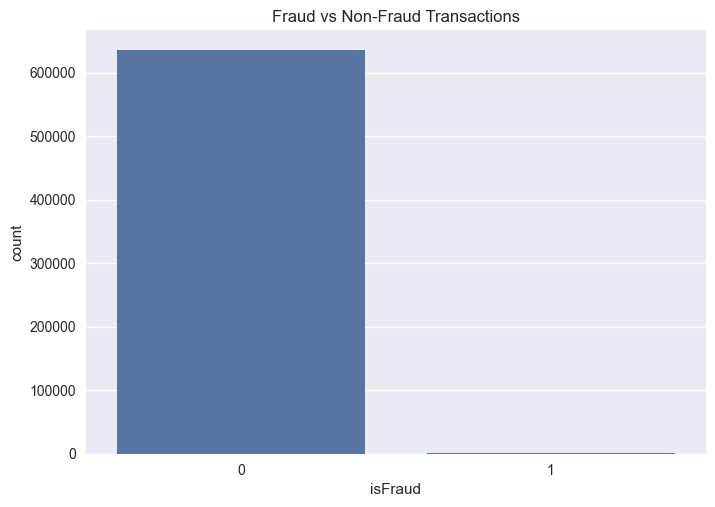

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

## FRAUD BY TRANSACTION TYPE (CRITICAL INSIGHT)

In [15]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,139694,0
CASH_OUT,223287,402
DEBIT,4093,0
PAYMENT,215342,0
TRANSFER,53029,415


## FILTER DATA (VERY IMPORTANT)

In [18]:
df = df[df["type"].isin(["CASH_OUT", "TRANSFER"])]

## UNDERSTAND FRAUD BEHAVIOR (AMOUNT ANALYSIS)

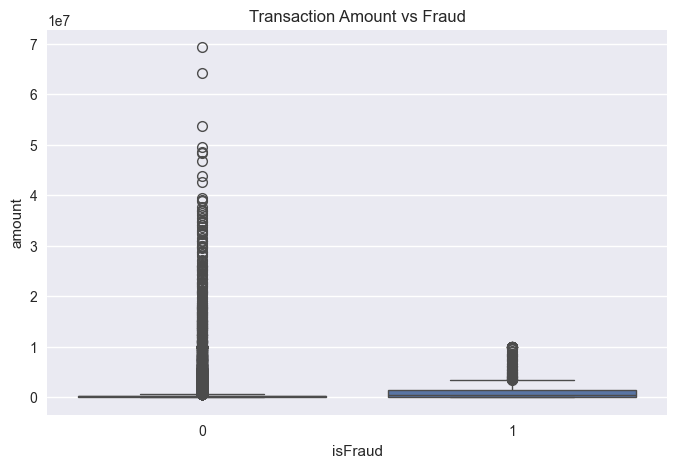

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

## CREATE NEW FEATURES

In [20]:
# Difference in sender balance
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

# Difference in receiver balance
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [21]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

## DROP USELESS COLUMNS

In [22]:
df = df.drop(columns=["nameOrig", "nameDest"])

## DEFINE FEATURES & TARGET

In [23]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

## TRAIN-TEST SPLIT

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## HANDLE IMBALANCE (IMPORTANT)

In [26]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

## TRAIN THE MODEL

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    print(f"\n{name}")
    
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     55252
           1       0.05      0.91      0.09       175

    accuracy                           0.94     55427
   macro avg       0.52      0.92      0.53     55427
weighted avg       1.00      0.94      0.97     55427


Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     55252
           1       0.07      0.97      0.13       175

    accuracy                           0.96     55427
   macro avg       0.53      0.96      0.55     55427
weighted avg       1.00      0.96      0.98     55427


Random Forest
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     55252
           1       0.10      0.97      0.18       175

    accuracy                           0.97     55427
   macro avg       0.55      0.97      0.58     55427
weighted avg       1.00

In [28]:
from sklearn.metrics import classification_report

best_model = None
best_recall = 0

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, m in models.items():
    m.fit(X_train_res, y_train_res)
    y_pred = m.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report["1"]["recall"]   # fraud recall

    print(f"{name} Recall: {recall}")

    if recall > best_recall:
        best_recall = recall
        best_model = m

Logistic Regression Recall: 0.9085714285714286
Decision Tree Recall: 0.9657142857142857
Random Forest Recall: 0.9771428571428571


In [29]:
print(f"Best Model Selected: {best_model}")

Best Model Selected: RandomForestClassifier()


In [32]:
import joblib

joblib.dump({
    "model": best_model,
    "recall": best_recall
}, "../../models/fraud/fraud_model.pkl")

['../../models/fraud/fraud_model.pkl']

In [33]:
X.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFlaggedFraud', 'balanceDiffOrig',
       'balanceDiffDest', 'type_TRANSFER'],
      dtype='object')